1) Run: The run number of the event.
 2) Lumi: The lumi section of the event.
  3) Event: The event number of the event. 
  4) MR: First razor kinematic variable, the MR variable is an estimate of an overall mass scale, which in the limit of massless decay products equals the mass of the heavy parent particle. 
  5) Rsq: Second razor kinematic variable, the Rsq variable is the square of the ratio R, which quantifies the flow of energy in the plane perpendicular to the beam and the partitioning of momentum between visible and invisible particles.
  6,7,8,9) E1,Px1,Py1,Pz1: The four-vector of the leading megajet (with the largest transverse momentum). 
  10,11,12,13) E2,Px2,Py2,Pz2: The four-vector of the subleading megajet (with the largest transverse momentum). 
  14) HT: The scalar sum of the transverse momentum of the jets. 
  15) MET: The magnitude of the vector sum of the transverse energy of the particles in the event.
   16) nJets: The number of jets with transverse momentum above 40 GeV. 
  17) nBJets: The number of b-tagged jets with transverse momentum above 40 GeV.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [80]:
p_df = pd.read_csv(r'C:\Users\DELL\Desktop\Data\datasets\raws\cern_proton_collisions\MultiJetRun2010B.csv')

In [81]:
p_df

,Run,Lumi,Event,MR,Rsq,E1,Px1,Py1,Pz1,E2,Px2,Py2,Pz2,HT,MET,nJets,nBJets
0,148029,388,302318745,215.553,0.031977,136.7100,-109.89300,-54.03420,-58.9032,142.1790,70.02540,41.12250,-116.5130,203.666,18.31100,2,0
1,148029,388,302323641,155.437,0.042157,83.3865,81.15000,6.88361,-12.9688,73.9025,-72.24720,11.88350,3.0899,154.659,14.77470,2,0
2,148029,388,302336217,400.563,0.026938,253.1840,139.90200,102.64000,-101.9350,535.5510,-110.37900,-89.09290,-516.1790,343.280,25.22110,3,0
3,148029,388,302382289,286.245,0.094192,175.4860,-156.02400,-62.95350,-47.7434,112.8510,89.08430,3.45025,67.9007,257.397,46.02880,2,0
4,148029,388,302403873,204.514,0.018804,833.7950,100.41000,-16.65900,-827.4980,445.6120,-91.19910,15.55830,-390.1440,269.492,8.11345,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21721,149181,1804,1703614264,540.609,0.019221,333.8870,43.55990,-102.70100,114.4280,517.8890,-13.42100,51.57390,-503.3490,393.455,50.30450,4,0
21722,149181,1804,1703630424,336.015,0.028433,190.1890,-7.40921,135.39000,132.1900,152.3330,-6.69605,-130.51800,-76.1992,266.282,23.12280,2,0
21723,149181,1804,1703621104,484.392,0.000920,197.1530,-61.55070,21.76930,110.9250,483.9510,47.52920,-37.96000,-470.8470,261.615,3.71479,4,0
21724,149181,1804,1703642752,215.713,0.055836,647.4060,-78.95460,-88.75690,636.3600,383.0890,80.57020,49.37650,371.1240,213.289,20.95540,2,0


In [82]:
p_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21726 entries, 0 to 21725
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Run     21726 non-null  int64  
 1   Lumi    21726 non-null  int64  
 2   Event   21726 non-null  int64  
 3   MR      21726 non-null  float64
 4   Rsq     21726 non-null  float64
 5   E1      21726 non-null  float64
 6   Px1     21726 non-null  float64
 7   Py1     21726 non-null  float64
 8   Pz1     21726 non-null  float64
 9   E2      21726 non-null  float64
 10  Px2     21726 non-null  float64
 11  Py2     21726 non-null  float64
 12  Pz2     21726 non-null  float64
 13  HT      21726 non-null  float64
 14  MET     21726 non-null  float64
 15  nJets   21726 non-null  int64  
 16  nBJets  21726 non-null  int64  
dtypes: float64(12), int64(5)
memory usage: 2.8 MB


In [83]:
p_df.duplicated().any()

np.False_

array([[<Axes: title={'center': 'Run'}>,
        <Axes: title={'center': 'Lumi'}>,
        <Axes: title={'center': 'Event'}>,
        <Axes: title={'center': 'MR'}>],
       [<Axes: title={'center': 'Rsq'}>, <Axes: title={'center': 'E1'}>,
        <Axes: title={'center': 'Px1'}>, <Axes: title={'center': 'Py1'}>],
       [<Axes: title={'center': 'Pz1'}>, <Axes: title={'center': 'E2'}>,
        <Axes: title={'center': 'Px2'}>, <Axes: title={'center': 'Py2'}>],
       [<Axes: title={'center': 'Pz2'}>, <Axes: title={'center': 'HT'}>,
        <Axes: title={'center': 'MET'}>,
        <Axes: title={'center': 'nJets'}>],
       [<Axes: title={'center': 'nBJets'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

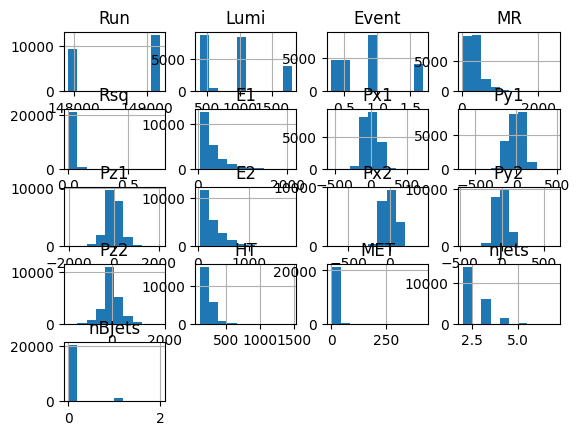

In [84]:
p_df.hist()

In [86]:
M_calc = np.sqrt(
    (p_df.E1 + p_df.E2)**2
    - (p_df.Px1 + p_df.Px2)**2
    - (p_df.Py1 + p_df.Py2)**2
    - (p_df.Pz1 + p_df.Pz2)**2
)

p_df['M_calc'] = M_calc

Text(0.5, 0, 'Invariant Mass [GeV]')

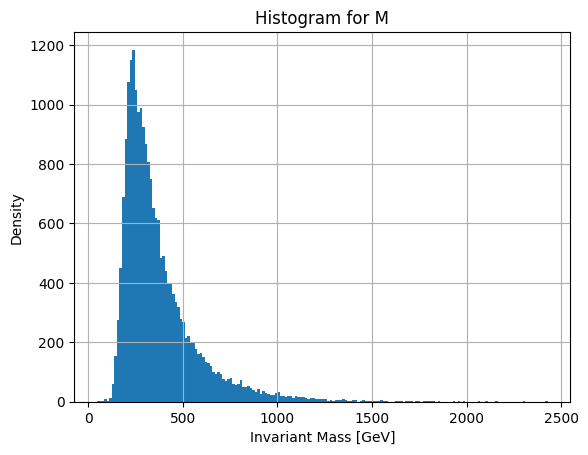

In [87]:
p_df.M_calc.hist(bins=180)
plt.title('Histogram for M')
plt.ylabel('Density')
plt.xlabel('Invariant Mass [GeV]')

<Axes: >

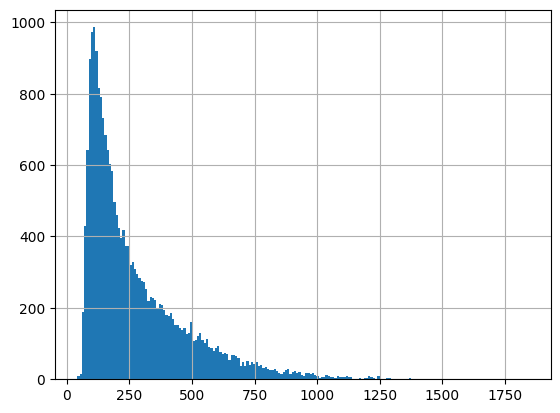

In [88]:
p_df.E2.hist(bins=200)

E1 and E2 histograms are very similar to M's.

p_df.duplica

In [90]:
p_df.loc[p_df.duplicated()]

,Run,Lumi,Event,MR,Rsq,E1,Px1,Py1,Pz1,E2,Px2,Py2,Pz2,HT,MET,nJets,nBJets,M_calc
